In [1]:
!pip install matplotlib numpy

In [2]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

print("Backend:", matplotlib.get_backend())

Backend: module://matplotlib_inline.backend_inline


Imports e configuraçãp

In [3]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

print("=" * 60)
print("Projeto C213 - Esteira Inteligente com Controle Fuzzy")
print("Modo Google Colab")
print("=" * 60)

CORES  = ['#E74C3C', '#E67E22', '#2ECC71', '#3498DB', '#9B59B6']
LABELS = ['NG', 'NP', 'Z', 'PP', 'PG']
LW     = 2.2

Projeto C213 - Esteira Inteligente com Controle Fuzzy
Modo Google Colab


Funções Fuzzy

In [4]:
def tri(x, a, b, c):
    return np.where(x <= a, 0.0,
           np.where(x >= c, 0.0,
           np.where(x <= b, (x-a)/(b-a), (c-x)/(c-b))))

def trapEsq(x, b, c):
    return np.where(x <= b, 1.0,
           np.where(x >= c, 0.0,
           (c-x)/(c-b)))

def trapDir(x, b, c):
    return np.where(x >= c, 1.0,
           np.where(x <= b, 0.0,
           (x-b)/(c-b)))

# ERRO

def eNG(e): return trapEsq(e,-400,-200)
def eNP(e): return tri(e,-400,-200,0)
def eZ(e):  return tri(e,-100,0,100)
def ePP(e): return tri(e,0,200,400)
def ePG(e): return trapDir(e,200,400)

# DELTA ERRO

def dNG(d): return trapEsq(d,-32,-16)
def dNP(d): return tri(d,-32,-16,0)
def dZ(d):  return tri(d,-8,0,8)
def dPP(d): return tri(d,0,16,32)
def dPG(d): return trapDir(d,16,32)

Matriz de regras

In [5]:
SAIDA = np.array([
    [-30,-30,-30,-15,0],
    [-30,-15,-15,0,15],
    [-15,-15,0,15,15],
    [-15,0,15,15,30],
    [0,15,30,30,30]
], dtype=float)

Inferência Fuzzy

In [6]:
def fuzzy_scalar(e,de):

    mE = [
        eNG(e),
        eNP(e),
        eZ(e),
        ePP(e),
        ePG(e)
    ]

    mD = [
        dNG(de),
        dNP(de),
        dZ(de),
        dPP(de),
        dPG(de)
    ]

    num = 0.0
    den = 0.0

    for i in range(5):
        for j in range(5):

            w = min(mE[i],mD[j])

            if w > 0:
                num += w * SAIDA[i][j]
                den += w

    return 0 if den == 0 else num/den

fuzzy_v = np.vectorize(fuzzy_scalar)

Parâmetros da planta

In [7]:
K  = 1.2
B  = 0.08
C  = 0.5
dt = 0.1

Gráfico erro

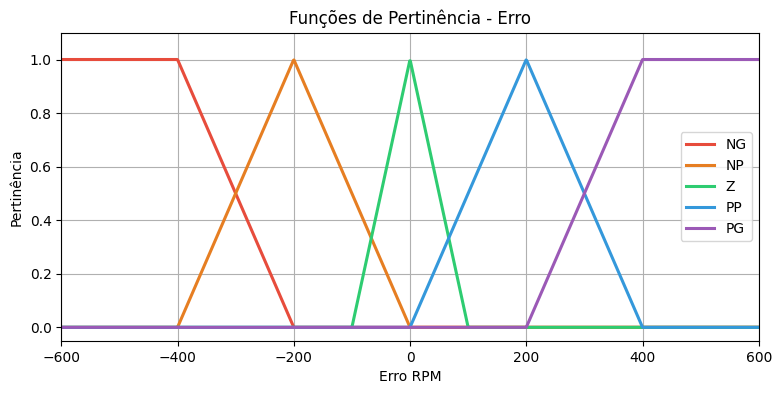

In [8]:
e = np.linspace(-600,600,1200)

plt.figure(figsize=(9,4))

for fn,cor,lab in zip(
    [eNG(e),eNP(e),eZ(e),ePP(e),ePG(e)],
    CORES,
    LABELS
):
    plt.plot(e,fn,color=cor,lw=LW,label=lab)

plt.title('Funções de Pertinência - Erro')
plt.xlabel('Erro RPM')
plt.ylabel('Pertinência')
plt.xlim(-600,600)
plt.ylim(-0.05,1.1)
plt.grid(True)
plt.legend()
plt.show()

Grafico derro

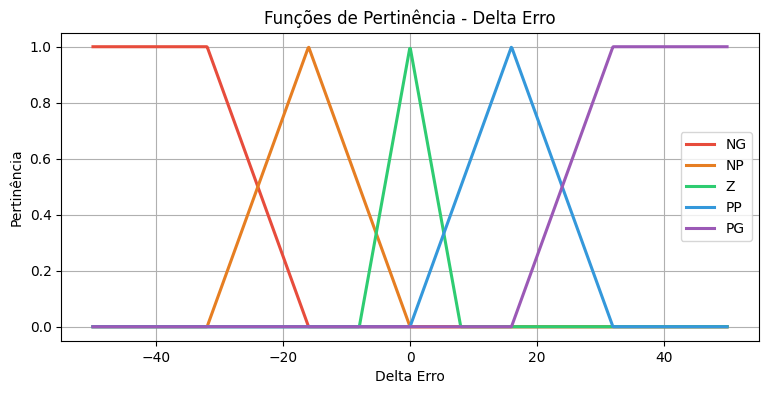

In [9]:
d = np.linspace(-50,50,1000)

plt.figure(figsize=(9,4))

for fn,cor,lab in zip(
    [dNG(d),dNP(d),dZ(d),dPP(d),dPG(d)],
    CORES,
    LABELS
):
    plt.plot(d,fn,color=cor,lw=LW,label=lab)

plt.title('Funções de Pertinência - Delta Erro')
plt.xlabel('Delta Erro')
plt.ylabel('Pertinência')
plt.grid(True)
plt.legend()
plt.show()

Singletons

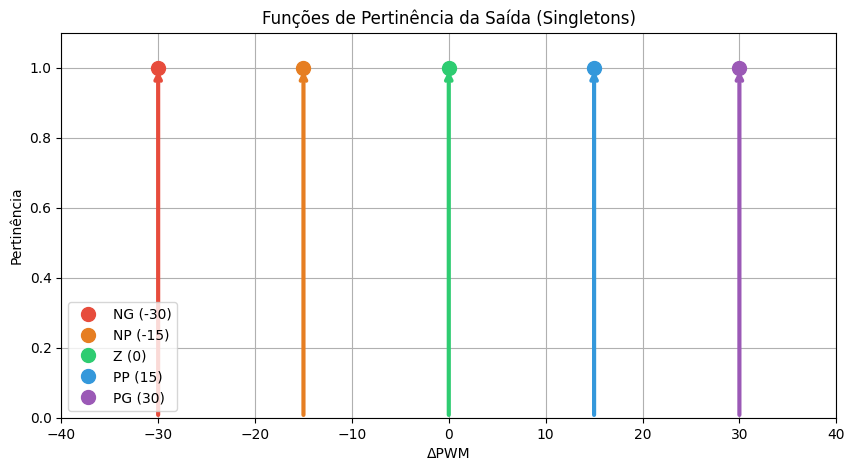

In [14]:
singletons = [-30, -15, 0, 15, 30]

plt.figure(figsize=(10,5))

for val, cor, lab in zip(singletons, CORES, LABELS):

    plt.annotate(
        '',
        xy=(val, 1.0),
        xytext=(val, 0.0),
        arrowprops=dict(
            arrowstyle='->',
            color=cor,
            lw=3
        )
    )

    plt.plot(
        val,
        1.0,
        'o',
        color=cor,
        markersize=10,
        label=f'{lab} ({val})'
    )

plt.title('Funções de Pertinência da Saída (Singletons)')
plt.xlabel('ΔPWM')
plt.ylabel('Pertinência')

# ESCALA NOVA
plt.xlim(-40, 40)
plt.ylim(0, 1.1)

plt.grid(True)
plt.legend()
plt.show()

Superfície

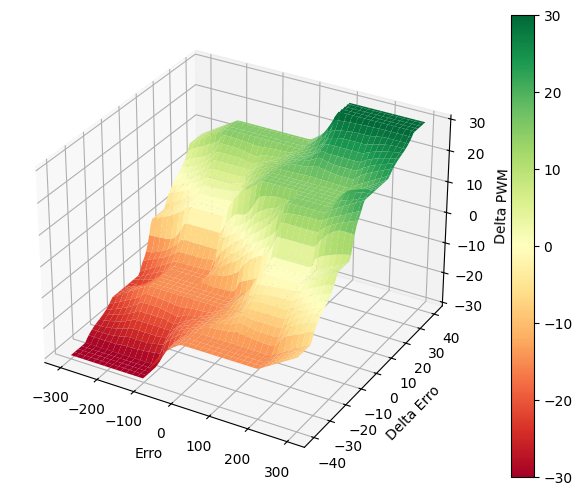

In [11]:
E  = np.linspace(-300,300,80)
DE = np.linspace(-40,40,80)

EE,DD = np.meshgrid(E,DE)

ZZ = fuzzy_v(EE,DD)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')

surf = ax.plot_surface(
    EE,
    DD,
    ZZ,
    cmap='RdYlGn'
)

fig.colorbar(surf)

ax.set_xlabel('Erro')
ax.set_ylabel('Delta Erro')
ax.set_zlabel('Delta PWM')

plt.show()

Resposta Temporal

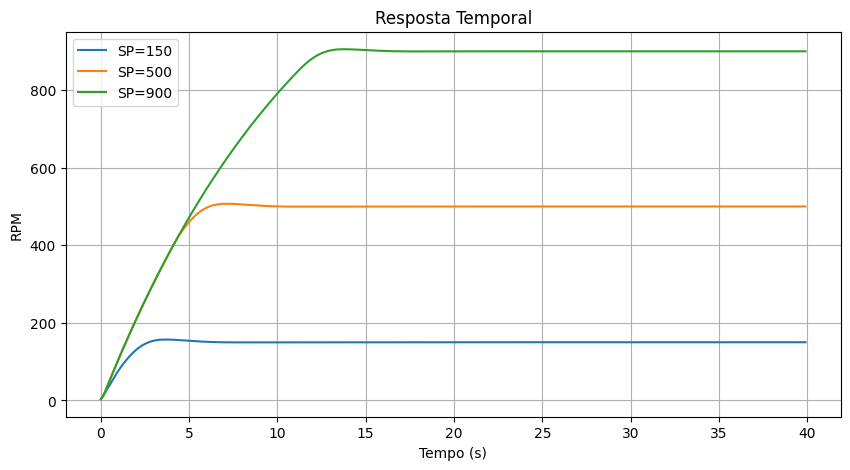

In [12]:
CARGA_SIM = 10

SETPOINTS = [150,500,900]

N = int(40/dt)

t = np.arange(N)*dt

plt.figure(figsize=(10,5))

for sp in SETPOINTS:

    rpm = 0
    pwm = 30

    erro = 0
    erroAnt = 0

    hist = []

    for _ in range(N):

        rpm += dt*(K*pwm - B*rpm - C*CARGA_SIM)

        rpm = np.clip(rpm,0,1000)

        erroAnt = erro
        erro = sp-rpm

        de = np.clip(erro-erroAnt,-40,40)

        pwm += fuzzy_scalar(erro,de)

        pwm = np.clip(pwm,0,100)

        hist.append(rpm)

    plt.plot(t,hist,label=f'SP={sp}')

plt.grid(True)
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('RPM')
plt.title('Resposta Temporal')
plt.show()

Perturbação

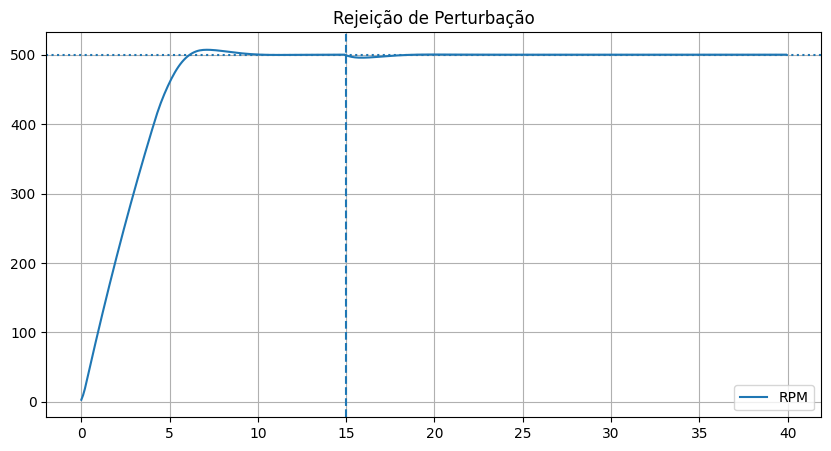

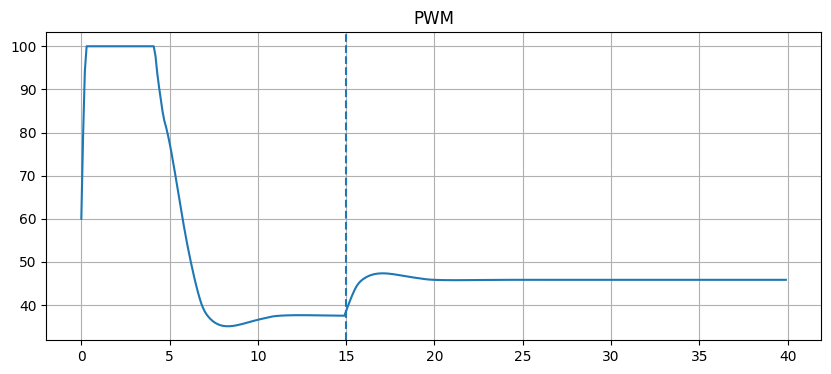

In [13]:
SP = 500

T_PERT = 15

N = int(40/dt)

t = np.arange(N)*dt

rpm = 0
pwm = 30

erro = 0
erroAnt = 0

hist_rpm = []
hist_pwm = []

for k in range(N):

    carga = 10 if t[k] < T_PERT else 30

    rpm += dt*(K*pwm - B*rpm - C*carga)

    rpm = np.clip(rpm,0,1000)

    erroAnt = erro
    erro = SP-rpm

    de = np.clip(erro-erroAnt,-40,40)

    pwm += fuzzy_scalar(erro,de)

    pwm = np.clip(pwm,0,100)

    hist_rpm.append(rpm)
    hist_pwm.append(pwm)

plt.figure(figsize=(10,5))
plt.plot(t,hist_rpm,label='RPM')
plt.axvline(T_PERT,ls='--')
plt.axhline(SP,ls=':')
plt.grid(True)
plt.legend()
plt.title('Rejeição de Perturbação')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(t,hist_pwm)
plt.axvline(T_PERT,ls='--')
plt.grid(True)
plt.title('PWM')
plt.show()